# Pixel Transformer student exercise solutions

This companion notebook shows one way to implement each idea for improving the model.

## Implementation hints before looking at the code

**1. Change the model capacity.**
Copy the exercise cell from notebook 02. You only need to change `hidden_dim` in the config. That value automatically flows into the input projection, each Transformer block, and the classifier head.

**2. Change the depth.**
Copy the same exercise cell and change `num_layers`. The relevant line is the `nn.ModuleList([... for _ in range(num_layers)])` inside `SimplePixelTransformer.__init__`; the `forward` loop already handles any number of blocks.

**3. Try a different pooling choice.**
Look near the end of `SimplePixelTransformer.forward`. The line to replace is the scaled-sum pooling line. For mean pooling, divide the masked sum by `mask.sum(dim=1)`. For mean+sum pooling, concatenate two pooled vectors and update the first classifier `Linear` layer to expect `2 * hidden_dim` inputs.

**4. Add light dropout.**
Add a `dropout` argument to the attention/block/model constructors. Put dropout after `attn.softmax(dim=-1)` and after the `GELU()` in the classifier head. The rest of the model can stay the same.

**5. Preprocess hit energy and time.**
Keep the padding mask based on the original raw energy. Then clone `x`, transform `x[:, :, 0]` with `log1p(clamp(...))`, transform `x[:, :, 1]` with `asinh`, and pass that preprocessed tensor into `self.input_layer`.

**6. Add primitive detector context.**
This is the only idea that needs a new model design. Load the context arrays from `clusters/`, standardize them with the train split, wrap each dataset so batches contain `X`, `C`, and `y`, then change the model signature from `forward(self, x)` to `forward(self, x, context)`.


## Setup

In [1]:
import sys, os, json, math, time, random
from pathlib import Path

# FILL THIS PATH!
PROJECT_ROOT = Path('/global/cfs/cdirs/m5197/sferrar2/ML4FPS')
TUTORIAL_DIR = PROJECT_ROOT / 'REAL_Jupyter/2026-gatech/sessions/04_muon_col/tutorial'

# Use the tutorial-local utilities and dataloader.
path_str = str(TUTORIAL_DIR)
if path_str in sys.path:
    sys.path.remove(path_str)
sys.path.insert(0, path_str)

import h5py
import joblib
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from dataloader import load_pixel_data
from tutorial_utils import (
    Trainer, build_feature_matrix, classifier_summary_row,
    plot_score_distributions, plot_confusion_matrix,
    plot_roc_comparison, plot_leaderboard,
    evaluate_classifier, predict_model,
    benchmark_model, benchmark_bdt, print_benchmark,
    count_parameters, display_model_card,
)


## Configuration


In [2]:
SIGNAL_H5 = str(PROJECT_ROOT / 'Samples_v2/signal.h5')
BIB_H5    = str(PROJECT_ROOT / 'Samples_v2/BIB.h5')

MAX_RAW_HITS = 50
TEST_FRACTION = 0.2
VAL_FRACTION  = 0.1
RANDOM_SEED   = 42
BATCH_SIZE    = 256

OUTPUT_DIR = TUTORIAL_DIR / 'simple_transformer_solution_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for required_path in [SIGNAL_H5, BIB_H5]:
    if not Path(required_path).exists():
        raise FileNotFoundError(required_path)


In [3]:
def get_device():
    device = 'cpu'
    if torch.cuda.is_available():
        try:
            torch.zeros(1).cuda()
            device = 'cuda'
        except RuntimeError:
            print('CUDA device found but not usable. Falling back to CPU.')
    return device


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_SEED)
device = get_device()
print('Using device:', device)


Using device: cuda


## Load raw-hit data


In [7]:
data = load_pixel_data(
    SIGNAL_H5, BIB_H5,
    max_hits=MAX_RAW_HITS,
    batch=BATCH_SIZE,
    test_frac=TEST_FRACTION,
    val_frac=VAL_FRACTION,
    seed=RANDOM_SEED,
)

train_loader = data['train']
val_loader   = data['val']
test_loader  = data['test']
idx_train = np.asarray(data['idx_train'])
idx_val   = np.asarray(data['idx_val'])
idx_test  = np.asarray(data['idx_test'])
labels    = np.asarray(data['labels']).astype(int)
CLUSTER_FEATURES = list(data['feature_keys'])

print(f"Total clusters: {len(labels):,}")
print(f"Signal: {labels.sum():,}, BIB: {(labels == 0).sum():,}")
print(f"Train: {len(idx_train):,}, Val: {len(idx_val):,}, Test: {len(idx_test):,}")

  Pre-loading 512222 samples from signal.h5...
  Raw features: ('energy', 'time', 'x', 'y')
  Done. Tensor shape: torch.Size([512222, 50, 4])
  Pre-loading 692442 samples from BIB.h5...
  Raw features: ('energy', 'time', 'x', 'y')
  Done. Tensor shape: torch.Size([692442, 50, 4])
  Loaded 1204664 clusters (512222 signal + 692442 BIB)
Total clusters: 1,204,664
Signal: 512,222, BIB: 692,442
Train: 843,264, Val: 120,467, Test: 240,933


## Reference model from notebook 02

The first two solutions only change the config for this model. Later solutions copy this class and edit a few lines.


In [5]:
class Attention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.q = nn.Linear(dim, dim)
        self.k = nn.Linear(dim, dim)
        self.v = nn.Linear(dim, dim)
        self.scale = dim ** -0.5

    def forward(self, x, mask):
        q = self.q(x)
        k = self.k(x)
        v = self.v(x)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        x = attn @ v

        return x * mask


class TransformerBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.att = Attention(dim)
        self.proj1 = nn.Linear(dim, dim)
        self.proj2 = nn.Linear(dim, dim)
        self.activation = nn.GELU()
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, x, mask):
        x = x + self.att(self.norm1(x), mask)
        x = self.activation(self.proj1(x)) * mask
        x = x + self.proj2(self.norm2(x)) * mask
        return x


class SimplePixelTransformer(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, num_layers=3, num_classes=2):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.blocks = nn.ModuleList([TransformerBlock(hidden_dim) for _ in range(num_layers)])
        self.output_layer = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        # A hit is real if the energy feature is nonzero.
        mask = (x[:, :, 0] != 0).unsqueeze(-1).float()

        x = self.input_layer(x) * mask
        for block in self.blocks:
            x = block(x, mask)

        # Sum pooling preserves extrema information better than a pure mean.
        x = (x * mask).sum(dim=1) / (mask.shape[1] ** 0.5)
        return self.output_layer(x)


## Solution 1: change model capacity

This is just the notebook 02 exercise cell with a wider `hidden_dim`.


In [25]:
class CapacityPixelTransformer(SimplePixelTransformer):
    pass

capacity_config = {
    'input_dim': 4,
    'hidden_dim': 128, # This Line!
    'num_layers': 3,
    'num_classes': 2,
}

TRAIN_CAPACITY_MODEL = True

if TRAIN_CAPACITY_MODEL:
    capacity_model = CapacityPixelTransformer(**capacity_config).to(device)
    display_model_card(capacity_model, capacity_config)
    trainer = Trainer(
        train_dataset=train_loader,
        val_dataset=val_loader,
        model=capacity_model,
        lr=2e-4,
        optimizer=torch.optim.Adam,
        loss_fn=nn.CrossEntropyLoss,
        device=device,
    )
    trainer.train(num_epochs=60, patience=8)
    capacity_model = trainer.model
    torch.save(capacity_model.state_dict(), OUTPUT_DIR / 'capacity_transformer_reference.pt')
else:
    capacity_model = None



### Pixel Transformer

| Setting | Value |
|---|---:|
| Input features | `4` |
| Hidden dimension | `128` |
| Transformer blocks | `3` |
| Output classes | `2` |
| Total parameters | `266,882` |
| Trainable parameters | `266,882` |


Epoch 1: train loss=0.6693, val loss=0.6529
Epoch 2: train loss=0.6549, val loss=0.6522
Epoch 3: train loss=0.6516, val loss=0.6311
Epoch 4: train loss=0.5892, val loss=0.5657
Epoch 5: train loss=0.5657, val loss=0.5331
Epoch 6: train loss=0.5534, val loss=0.5656
Epoch 7: train loss=0.5412, val loss=0.5370
Epoch 8: train loss=0.5311, val loss=0.5287
Epoch 9: train loss=0.5276, val loss=0.5180
Epoch 10: train loss=0.5223, val loss=0.5138
Epoch 11: train loss=0.5224, val loss=0.5210
Epoch 12: train loss=0.5216, val loss=0.5259
Epoch 13: train loss=0.5171, val loss=0.5274
Epoch 14: train loss=0.5161, val loss=0.5059
Epoch 15: train loss=0.5156, val loss=0.5114
Epoch 16: train loss=0.5142, val loss=0.5078
Epoch 17: train loss=0.5138, val loss=0.5173
Epoch 18: train loss=0.5125, val loss=0.5112
Epoch 19: train loss=0.5116, val loss=0.5129
Epoch 20: train loss=0.5119, val loss=0.5177
Epoch 21: train loss=0.5109, val loss=0.5046
Epoch 22: train loss=0.5107, val loss=0.5067
Epoch 23: train los

## Solution 2: change model depth

Same model, different `num_layers`.


In [26]:
class DeeperPixelTransformer(SimplePixelTransformer):
    pass

depth_config = {
    'input_dim': 4,
    'hidden_dim': 64,
    'num_layers': 4, # This Line!
    'num_classes': 2,
}

TRAIN_DEPTH_MODEL = True

if TRAIN_DEPTH_MODEL:
    depth_model = DeeperPixelTransformer(**depth_config).to(device)
    display_model_card(depth_model, depth_config)
    trainer = Trainer(
        train_dataset=train_loader,
        val_dataset=val_loader,
        model=depth_model,
        lr=3e-4,
        optimizer=torch.optim.Adam,
        loss_fn=nn.CrossEntropyLoss,
        device=device,
    )
    trainer.train(num_epochs=60, patience=8)
    depth_model = trainer.model
    torch.save(depth_model.state_dict(), OUTPUT_DIR / 'depth_transformer_reference.pt')
else:
    depth_model = None



### Pixel Transformer

| Setting | Value |
|---|---:|
| Input features | `4` |
| Hidden dimension | `64` |
| Transformer blocks | `4` |
| Output classes | `2` |
| Total parameters | `88,962` |
| Trainable parameters | `88,962` |


Epoch 1: train loss=0.6651, val loss=0.6533
Epoch 2: train loss=0.6533, val loss=0.6420
Epoch 3: train loss=0.6051, val loss=0.5597
Epoch 4: train loss=0.5442, val loss=0.5228
Epoch 5: train loss=0.5290, val loss=0.5397
Epoch 6: train loss=0.5247, val loss=0.5235
Epoch 7: train loss=0.5207, val loss=0.5204
Epoch 8: train loss=0.5189, val loss=0.5414
Epoch 9: train loss=0.5168, val loss=0.5095
Epoch 10: train loss=0.5149, val loss=0.5121
Epoch 11: train loss=0.5156, val loss=0.5221
Epoch 12: train loss=0.5123, val loss=0.5052
Epoch 13: train loss=0.5101, val loss=0.5036
Epoch 14: train loss=0.5094, val loss=0.5111
Epoch 15: train loss=0.5086, val loss=0.5100
Epoch 16: train loss=0.5080, val loss=0.5003
Epoch 17: train loss=0.5073, val loss=0.5036
Epoch 18: train loss=0.5075, val loss=0.5029
Epoch 19: train loss=0.5058, val loss=0.5053
Epoch 20: train loss=0.5072, val loss=0.4989
Epoch 21: train loss=0.5063, val loss=0.5134
Epoch 22: train loss=0.5050, val loss=0.5053
Epoch 23: train los

## Solution 3: change pooling

Here the changed lines are in `forward`. The classifier input dimension also changes for `mean_sum`, because the pooled representation is twice as wide.


In [27]:
class MeanSumPoolingPixelTransformer(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, num_layers=3, num_classes=2):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.blocks = nn.ModuleList([TransformerBlock(hidden_dim) for _ in range(num_layers)])
        self.output_layer = nn.Sequential(
            nn.LayerNorm(2 * hidden_dim),
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        mask = (x[:, :, 0] != 0).unsqueeze(-1).float()

        x = self.input_layer(x) * mask
        for block in self.blocks:
            x = block(x, mask)

        n_hits = mask.sum(dim=1).clamp(min=1)
        # If you just want to use sum pooling, you can skip the mean and scaling steps and feed x_sum directly to the output layer.
        # But this way we can give the model both the mean and sum information, which may help it learn better.
        # You can also experiment with other pooling strategies, like max pooling or attention-based pooling, if you want to get creative!
        x_sum = (x * mask).sum(dim=1) 
        x_mean = x_sum / n_hits
        x_sum_scaled = x_sum / (mask.shape[1] ** 0.5)
        x = torch.cat([x_mean, x_sum_scaled], dim=-1)

        return self.output_layer(x)


pooling_config = {
    'input_dim': 4,
    'hidden_dim': 64,
    'num_layers': 3,
    'num_classes': 2,
}

TRAIN_POOLING_MODEL = True

if TRAIN_POOLING_MODEL:
    pooling_model = MeanSumPoolingPixelTransformer(**pooling_config).to(device)
    display_model_card(pooling_model, pooling_config)
    trainer = Trainer(
        train_dataset=train_loader,
        val_dataset=val_loader,
        model=pooling_model,
        lr=3e-4,
        optimizer=torch.optim.Adam,
        loss_fn=nn.CrossEntropyLoss,
        device=device,
    )
    trainer.train(num_epochs=60, patience=8)
    pooling_model = trainer.model
    torch.save(pooling_model.state_dict(), OUTPUT_DIR / 'pooling_transformer_reference.pt')
else:
    pooling_model = None



### Pixel Transformer

| Setting | Value |
|---|---:|
| Input features | `4` |
| Hidden dimension | `64` |
| Transformer blocks | `3` |
| Output classes | `2` |
| Total parameters | `72,130` |
| Trainable parameters | `72,130` |


Epoch 1: train loss=0.6598, val loss=0.6556
Epoch 2: train loss=0.6484, val loss=0.6055
Epoch 3: train loss=0.5670, val loss=0.5506
Epoch 4: train loss=0.5375, val loss=0.5329
Epoch 5: train loss=0.5263, val loss=0.5404
Epoch 6: train loss=0.5227, val loss=0.5107
Epoch 7: train loss=0.5190, val loss=0.5156
Epoch 8: train loss=0.5167, val loss=0.5311
Epoch 9: train loss=0.5155, val loss=0.5106
Epoch 10: train loss=0.5134, val loss=0.5106
Epoch 11: train loss=0.5125, val loss=0.5066
Epoch 12: train loss=0.5130, val loss=0.5190
Epoch 13: train loss=0.5104, val loss=0.5019
Epoch 14: train loss=0.5099, val loss=0.5060
Epoch 15: train loss=0.5111, val loss=0.5007
Epoch 16: train loss=0.5094, val loss=0.5018
Epoch 17: train loss=0.5087, val loss=0.5015
Epoch 18: train loss=0.5086, val loss=0.5074
Epoch 19: train loss=0.5072, val loss=0.5031
Epoch 20: train loss=0.5134, val loss=0.5015
Epoch 21: train loss=0.5068, val loss=0.5032
Epoch 22: train loss=0.5057, val loss=0.4971
Epoch 23: train los

## Solution 4: add light dropout

In [28]:
class DropoutAttention(nn.Module):
    def __init__(self, dim, dropout=0.05):
        super().__init__()
        self.q = nn.Linear(dim, dim)
        self.k = nn.Linear(dim, dim)
        self.v = nn.Linear(dim, dim)
        self.dropout = nn.Dropout(dropout) # Dropout layer for attention weights!
        self.scale = dim ** -0.5

    def forward(self, x, mask):
        q = self.q(x)
        k = self.k(x)
        v = self.v(x)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = self.dropout(attn.softmax(dim=-1)) # Apply dropout to attention weights!
        x = attn @ v

        return x * mask


class DropoutTransformerBlock(nn.Module):
    def __init__(self, dim, dropout=0.05):
        super().__init__()
        self.att = DropoutAttention(dim, dropout=dropout) # Use the dropout attention layer!
        self.proj1 = nn.Linear(dim, dim)
        self.proj2 = nn.Linear(dim, dim)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout) # Dropout layer for the feedforward output!
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, x, mask):
        x = x + self.att(self.norm1(x), mask)
        x = self.activation(self.proj1(x)) * mask
        x = x + self.dropout(self.proj2(self.norm2(x))) * mask # Apply dropout to the feedforward output!
        return x


class DropoutPixelTransformer(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, num_layers=3, num_classes=2, dropout=0.05):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.blocks = nn.ModuleList([
            DropoutTransformerBlock(hidden_dim, dropout=dropout) for _ in range(num_layers)
        ])
        self.output_layer = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout), # Dropout layer before the output layer!
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        mask = (x[:, :, 0] != 0).unsqueeze(-1).float()

        x = self.input_layer(x) * mask
        for block in self.blocks:
            x = block(x, mask)

        x = (x * mask).sum(dim=1) / (mask.shape[1] ** 0.5)
        return self.output_layer(x)


dropout_config = {
    'input_dim': 4,
    'hidden_dim': 64,
    'num_layers': 3,
    'num_classes': 2,
    'dropout': 0.05,
}

TRAIN_DROPOUT_MODEL = True

if TRAIN_DROPOUT_MODEL:
    dropout_model = DropoutPixelTransformer(**dropout_config).to(device)
    display_model_card(dropout_model, {k: dropout_config[k] for k in ['input_dim', 'hidden_dim', 'num_layers', 'num_classes']})
    trainer = Trainer(
        train_dataset=train_loader,
        val_dataset=val_loader,
        model=dropout_model,
        lr=3e-4,
        optimizer=torch.optim.Adam,
        loss_fn=nn.CrossEntropyLoss,
        device=device,
    )
    trainer.train(num_epochs=60, patience=8)
    dropout_model = trainer.model
    torch.save(dropout_model.state_dict(), OUTPUT_DIR / 'dropout_transformer_reference.pt')
else:
    dropout_model = None



### Pixel Transformer

| Setting | Value |
|---|---:|
| Input features | `4` |
| Hidden dimension | `64` |
| Transformer blocks | `3` |
| Output classes | `2` |
| Total parameters | `67,906` |
| Trainable parameters | `67,906` |


Epoch 1: train loss=0.6701, val loss=0.6580
Epoch 2: train loss=0.6541, val loss=0.6656
Epoch 3: train loss=0.6025, val loss=0.5779
Epoch 4: train loss=0.5678, val loss=0.5561
Epoch 5: train loss=0.5422, val loss=0.5266
Epoch 6: train loss=0.5317, val loss=0.5134
Epoch 7: train loss=0.5257, val loss=0.5082
Epoch 8: train loss=0.5235, val loss=0.5129
Epoch 9: train loss=0.5212, val loss=0.5126
Epoch 10: train loss=0.5197, val loss=0.5637
Epoch 11: train loss=0.5178, val loss=0.5110
Epoch 12: train loss=0.5171, val loss=0.5096
Epoch 13: train loss=0.5165, val loss=0.5028
Epoch 14: train loss=0.5155, val loss=0.5092
Epoch 15: train loss=0.5141, val loss=0.5095
Epoch 16: train loss=0.5127, val loss=0.5136
Epoch 17: train loss=0.5111, val loss=0.5172
Epoch 18: train loss=0.5105, val loss=0.4991
Epoch 19: train loss=0.5098, val loss=0.5098
Epoch 20: train loss=0.5084, val loss=0.5057
Epoch 21: train loss=0.5078, val loss=0.5103
Epoch 22: train loss=0.5077, val loss=0.4992
Epoch 23: train los

## Solution 5: preprocess energy and time

In [29]:
class PreprocessedPixelTransformer(SimplePixelTransformer):
    # You can experiment with different preprocessing strategies here! Just make sure to keep the output shape the same.
    def preprocess_hits(self, x):
        x = x.clone()
        x[:, :, 0] = torch.log1p(torch.clamp(x[:, :, 0], min=0))
        x[:, :, 1] = torch.asinh(x[:, :, 1])
        return x

    def forward(self, x):
        # Build the mask before preprocessing, while padded hits are still exactly zero.
        mask = (x[:, :, 0] != 0).unsqueeze(-1).float()

        x = self.preprocess_hits(x) # Apply preprocessing to the raw hit features!
        x = self.input_layer(x) * mask
        for block in self.blocks:
            x = block(x, mask)

        x = (x * mask).sum(dim=1) / (mask.shape[1] ** 0.5)
        return self.output_layer(x)


preprocess_config = {
    'input_dim': 4,
    'hidden_dim': 64,
    'num_layers': 3,
    'num_classes': 2,
}

TRAIN_PREPROCESS_MODEL = True

if TRAIN_PREPROCESS_MODEL:
    preprocess_model = PreprocessedPixelTransformer(**preprocess_config).to(device)
    display_model_card(preprocess_model, preprocess_config)
    trainer = Trainer(
        train_dataset=train_loader,
        val_dataset=val_loader,
        model=preprocess_model,
        lr=3e-4,
        optimizer=torch.optim.Adam,
        loss_fn=nn.CrossEntropyLoss,
        device=device,
    )
    trainer.train(num_epochs=60, patience=8)
    preprocess_model = trainer.model
    torch.save(preprocess_model.state_dict(), OUTPUT_DIR / 'preprocess_transformer_reference.pt')
else:
    preprocess_model = None



### Pixel Transformer

| Setting | Value |
|---|---:|
| Input features | `4` |
| Hidden dimension | `64` |
| Transformer blocks | `3` |
| Output classes | `2` |
| Total parameters | `67,906` |
| Trainable parameters | `67,906` |


Epoch 1: train loss=0.6794, val loss=0.6553
Epoch 2: train loss=0.5629, val loss=0.5096
Epoch 3: train loss=0.5169, val loss=0.5064
Epoch 4: train loss=0.5111, val loss=0.5098
Epoch 5: train loss=0.5073, val loss=0.4951
Epoch 6: train loss=0.5049, val loss=0.4976
Epoch 7: train loss=0.5035, val loss=0.4951
Epoch 8: train loss=0.5031, val loss=0.4962
Epoch 9: train loss=0.5016, val loss=0.5009
Epoch 10: train loss=0.5008, val loss=0.5043
Epoch 11: train loss=0.5003, val loss=0.4967
Epoch 12: train loss=0.4997, val loss=0.4944
Epoch 13: train loss=0.4993, val loss=0.4934
Epoch 14: train loss=0.4983, val loss=0.5025
Epoch 15: train loss=0.4979, val loss=0.4935
Epoch 16: train loss=0.4970, val loss=0.4946
Epoch 17: train loss=0.4969, val loss=0.4965
Epoch 18: train loss=0.4966, val loss=0.4935
Epoch 19: train loss=0.4962, val loss=0.4916
Epoch 20: train loss=0.4960, val loss=0.4954
Epoch 21: train loss=0.4960, val loss=0.4912
Epoch 22: train loss=0.4952, val loss=0.4919
Epoch 23: train los

## Solution 6: add primitive detector context

This one cannot use the default `Trainer` directly because each batch now needs `X`, `C`, and `y`. The model change is still small: embed context and concatenate it to the pooled hit representation before classification.


In [8]:
CONTEXT_KEYS = ['cluster_x', 'cluster_y', 'cluster_z', 'cluster_r', 'cluster_size_x']


def load_context_features(signal_h5, bib_h5, keys):
    arrays = []
    for path in [signal_h5, bib_h5]:
        with h5py.File(path, 'r') as f:
            arrays.append(np.stack([f['clusters'][key][:] for key in keys], axis=1).astype('float32'))
    return np.concatenate(arrays, axis=0)

# You don't need to do this, but Transformers can be a bit more sensitive to feature scaling than some other models, 
# so standardizing the context features may help the model learn better.
def standardize_context(context, train_indices):
    mean = context[train_indices].mean(axis=0, keepdims=True)
    std = context[train_indices].std(axis=0, keepdims=True) + 1e-6
    return (context - mean) / std


class DatasetWithContext(Dataset):
    def __init__(self, base_dataset, context_array):
        self.base_dataset = base_dataset
        self.context = torch.as_tensor(context_array, dtype=torch.float32)

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        item = self.base_dataset[idx]
        return {'X': item['X'], 'C': self.context[idx], 'y': item['y']}


context_all = load_context_features(SIGNAL_H5, BIB_H5, CONTEXT_KEYS)
context_all = standardize_context(context_all, idx_train)

train_loader_ctx = DataLoader(
    DatasetWithContext(train_loader.dataset, context_all[idx_train]),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)
val_loader_ctx = DataLoader(
    DatasetWithContext(val_loader.dataset, context_all[idx_val]),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
test_loader_ctx = DataLoader(
    DatasetWithContext(test_loader.dataset, context_all[idx_test]),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)


In [9]:
class ContextHeadPixelTransformer(SimplePixelTransformer):
    def __init__(self, input_dim=4, context_dim=4, hidden_dim=64, num_layers=3, num_classes=2, context_hidden_dim=16):
        super().__init__(input_dim=input_dim, hidden_dim=hidden_dim, num_layers=num_layers, num_classes=num_classes)
        self.context_layer = nn.Sequential(
            nn.LayerNorm(context_dim),
            nn.Linear(context_dim, context_hidden_dim),
            nn.GELU(),
        )
        self.output_layer = nn.Sequential(
            nn.LayerNorm(hidden_dim + context_hidden_dim),
            nn.Linear(hidden_dim + context_hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x, context):
        mask = (x[:, :, 0] != 0).unsqueeze(-1).float()

        x = self.input_layer(x) * mask
        for block in self.blocks:
            x = block(x, mask)

        x = (x * mask).sum(dim=1) / (mask.shape[1] ** 0.5)
        context = self.context_layer(context)
        x = torch.cat([x, context], dim=-1)
        return self.output_layer(x)


context_config = {
    'input_dim': 4,
    'context_dim': len(CONTEXT_KEYS),
    'hidden_dim': 64,
    'num_layers': 3,
    'num_classes': 2,
    'context_hidden_dim': 16,
}

TRAIN_CONTEXT_MODEL = True

if TRAIN_CONTEXT_MODEL:
    context_model = ContextHeadPixelTransformer(**context_config).to(device)
    optimizer = torch.optim.Adam(context_model.parameters(), lr=3e-4)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(1, 61):
        context_model.train()
        train_losses = []
        for batch in train_loader_ctx:
            X = batch['X'].to(device)
            C = batch['C'].to(device)
            y = batch['y'].to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(context_model(X, C), y)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        context_model.eval()
        val_losses = []
        with torch.no_grad():
            for batch in val_loader_ctx:
                X = batch['X'].to(device)
                C = batch['C'].to(device)
                y = batch['y'].to(device)
                val_losses.append(loss_fn(context_model(X, C), y).item())
        print(f'Epoch {epoch}: train loss={np.mean(train_losses):.4f}, val loss={np.mean(val_losses):.4f}')
    torch.save(context_model.state_dict(), OUTPUT_DIR / 'context_head_transformer_reference.pt')
else:
    context_model = None


Epoch 1: train loss=0.6707, val loss=0.6444
Epoch 2: train loss=0.6385, val loss=0.6073
Epoch 3: train loss=0.5584, val loss=0.5302
Epoch 4: train loss=0.5294, val loss=0.5210
Epoch 5: train loss=0.5127, val loss=0.4965
Epoch 6: train loss=0.5061, val loss=0.5529
Epoch 7: train loss=0.5064, val loss=0.5109
Epoch 8: train loss=0.4994, val loss=0.4963
Epoch 9: train loss=0.4961, val loss=0.4891
Epoch 10: train loss=0.4931, val loss=0.5016
Epoch 11: train loss=0.4929, val loss=0.5013
Epoch 12: train loss=0.4904, val loss=0.4819
Epoch 13: train loss=0.4874, val loss=0.5076
Epoch 14: train loss=0.4872, val loss=0.4806
Epoch 15: train loss=0.4849, val loss=0.4820
Epoch 16: train loss=0.4835, val loss=0.4799
Epoch 17: train loss=0.4816, val loss=0.4807
Epoch 18: train loss=0.4806, val loss=0.4779
Epoch 19: train loss=0.4815, val loss=0.4775
Epoch 20: train loss=0.4795, val loss=0.4811
Epoch 21: train loss=0.4787, val loss=0.4755
Epoch 22: train loss=0.4815, val loss=0.4778
Epoch 23: train los

## Solution 6.1: broadcast primitive detector context

This uses the same context data as Solution 6, but moves the context earlier. Instead of concatenating context after pooling, embed the context, copy it to every hit, concatenate it with the hit features, and then run the Transformer.


In [10]:
class ContextBroadcastPixelTransformer(SimplePixelTransformer):
    def __init__(self, input_dim=4, context_dim=4, hidden_dim=64, num_layers=3, num_classes=2, context_hidden_dim=16):
        super().__init__(input_dim=input_dim, hidden_dim=hidden_dim, num_layers=num_layers, num_classes=num_classes)
        self.context_layer = nn.Sequential(
            nn.LayerNorm(context_dim),
            nn.Linear(context_dim, context_hidden_dim),
            nn.GELU(),
        )
        self.input_layer = nn.Linear(input_dim + context_hidden_dim, hidden_dim)

    def forward(self, x, context):
        mask = (x[:, :, 0] != 0).unsqueeze(-1).float()

        context = self.context_layer(context)
        context = context.unsqueeze(1).expand(-1, x.shape[1], -1)
        x = torch.cat([x, context], dim=-1)

        x = self.input_layer(x) * mask
        for block in self.blocks:
            x = block(x, mask)

        x = (x * mask).sum(dim=1) / (mask.shape[1] ** 0.5)
        return self.output_layer(x)


broadcast_context_config = {
    'input_dim': 4,
    'context_dim': len(CONTEXT_KEYS),
    'hidden_dim': 64,
    'num_layers': 3,
    'num_classes': 2,
    'context_hidden_dim': 16,
}

TRAIN_BROADCAST_CONTEXT_MODEL = True

if TRAIN_BROADCAST_CONTEXT_MODEL:
    broadcast_context_model = ContextBroadcastPixelTransformer(**broadcast_context_config).to(device)
    optimizer = torch.optim.Adam(broadcast_context_model.parameters(), lr=3e-4)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(1, 61):
        broadcast_context_model.train()
        train_losses = []
        for batch in train_loader_ctx:
            X = batch['X'].to(device)
            C = batch['C'].to(device)
            y = batch['y'].to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(broadcast_context_model(X, C), y)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        broadcast_context_model.eval()
        val_losses = []
        with torch.no_grad():
            for batch in val_loader_ctx:
                X = batch['X'].to(device)
                C = batch['C'].to(device)
                y = batch['y'].to(device)
                val_losses.append(loss_fn(broadcast_context_model(X, C), y).item())
        print(f'Epoch {epoch}: train loss={np.mean(train_losses):.4f}, val loss={np.mean(val_losses):.4f}')
    torch.save(broadcast_context_model.state_dict(), OUTPUT_DIR / 'context_broadcast_transformer_reference.pt')
else:
    broadcast_context_model = None


Epoch 1: train loss=0.6714, val loss=0.6523
Epoch 2: train loss=0.6034, val loss=0.5610
Epoch 3: train loss=0.5550, val loss=0.5587
Epoch 4: train loss=0.5401, val loss=0.6006
Epoch 5: train loss=0.5208, val loss=0.5157
Epoch 6: train loss=0.5051, val loss=0.5015
Epoch 7: train loss=0.5070, val loss=0.4872
Epoch 8: train loss=0.4975, val loss=0.4808
Epoch 9: train loss=0.4926, val loss=0.5401
Epoch 10: train loss=0.4924, val loss=0.4795
Epoch 11: train loss=0.4957, val loss=0.4790
Epoch 12: train loss=0.4904, val loss=0.4956
Epoch 13: train loss=0.4856, val loss=0.4743
Epoch 14: train loss=0.4844, val loss=0.4732
Epoch 15: train loss=0.4832, val loss=0.4789
Epoch 16: train loss=0.4896, val loss=0.4758
Epoch 17: train loss=0.4813, val loss=0.4755
Epoch 18: train loss=0.4793, val loss=0.4760
Epoch 19: train loss=0.4797, val loss=0.4738
Epoch 20: train loss=0.4773, val loss=0.4734
Epoch 21: train loss=0.4791, val loss=0.4803
Epoch 22: train loss=0.4765, val loss=0.4716
Epoch 23: train los

## Optional visual check after training

If you train one of the solutions above, this cell makes the same style of plots as the end of notebook 02. Context models use `test_loader_ctx` because their batches include `C`.



context_head AUC: 0.8534
Accuracy: 0.7697
  Signal eff = 0.500  ->  1 - BIB eff = 0.9334
  Signal eff = 0.800  ->  1 - BIB eff = 0.7101
  Signal eff = 0.900  ->  1 - BIB eff = 0.5628
  Signal eff = 0.950  ->  1 - BIB eff = 0.4690


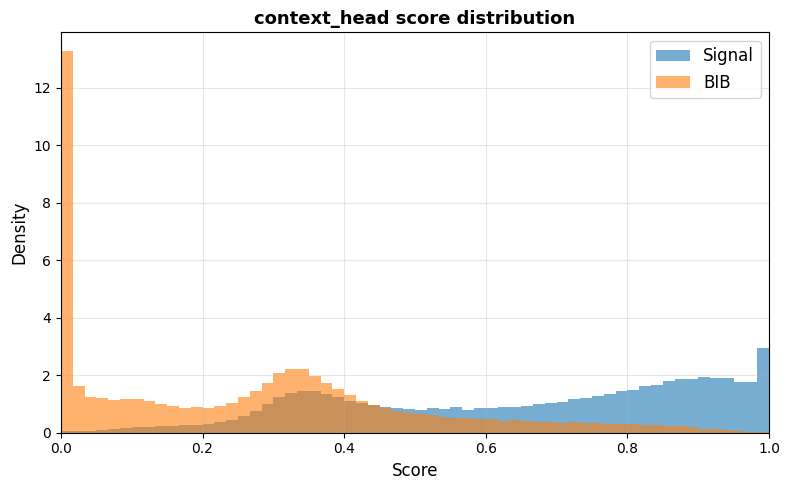

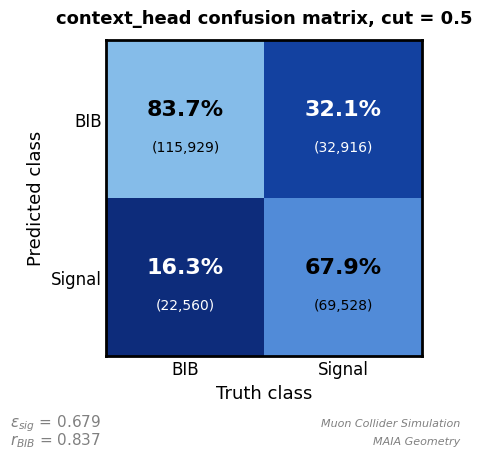


context_broadcast AUC: 0.8565
Accuracy: 0.7728
  Signal eff = 0.500  ->  1 - BIB eff = 0.9351
  Signal eff = 0.800  ->  1 - BIB eff = 0.7165
  Signal eff = 0.900  ->  1 - BIB eff = 0.5711
  Signal eff = 0.950  ->  1 - BIB eff = 0.4783


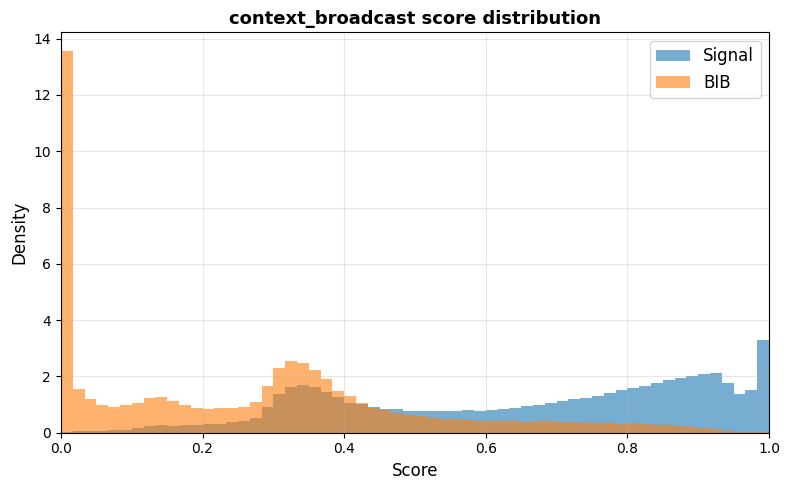

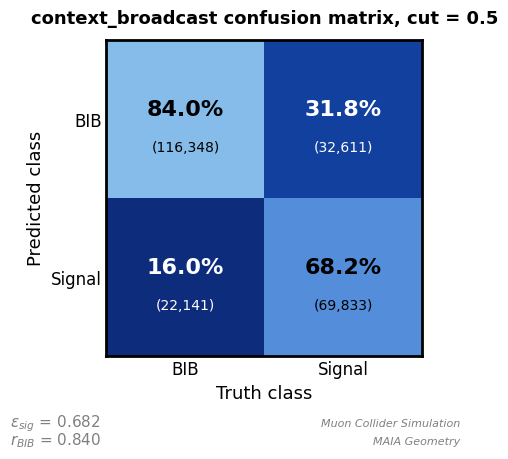

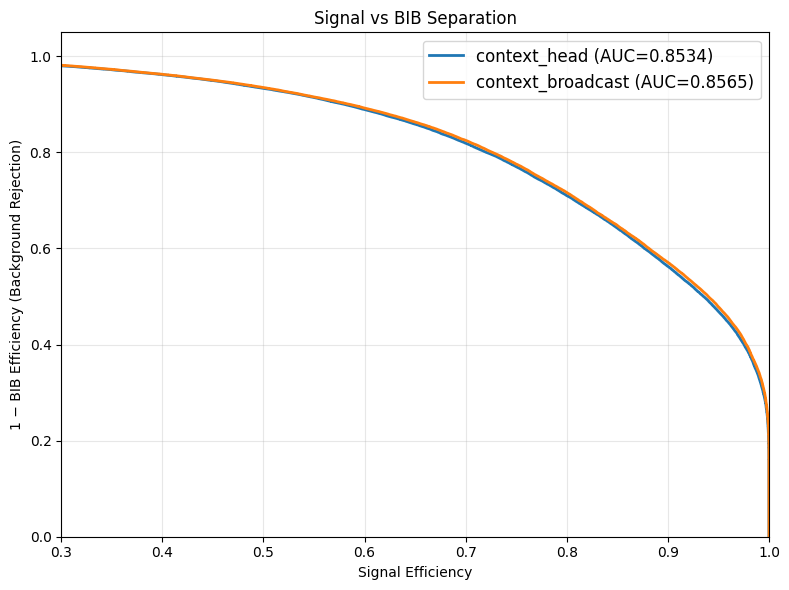

In [12]:
trained_solution_models = {
    # 'capacity': capacity_model,
    # 'depth': depth_model,
    # 'pooling': pooling_model,
    # 'dropout': dropout_model,
    # 'preprocess': preprocess_model,
}

roc_payload = {}
for name, model in trained_solution_models.items():
    if model is None:
        continue
    scores, y = predict_model(model, test_loader, device)
    roc_payload[name] = evaluate_classifier(y, scores, name)
    plot_score_distributions(y, scores, title=f'{name} score distribution')
    plot_confusion_matrix(y, scores, cut=0.5, title=f'{name} confusion matrix, cut = 0.5')

trained_context_models = {
    'context_head': context_model,
    'context_broadcast': broadcast_context_model,
}
for name, model in trained_context_models.items():
    if model is None:
        continue
    model.eval()
    scores, y = [], []
    with torch.no_grad():
        for batch in test_loader_ctx:
            X = batch['X'].to(device)
            C = batch['C'].to(device)
            logits = model(X, C)
            scores.append(torch.softmax(logits, dim=1)[:, 1].cpu())
            y.append(batch['y'].cpu())
    scores = torch.cat(scores).numpy()
    y = torch.cat(y).numpy()
    roc_payload[name] = evaluate_classifier(y, scores, name)
    plot_score_distributions(y, scores, title=f'{name} score distribution')
    plot_confusion_matrix(y, scores, cut=0.5, title=f'{name} confusion matrix, cut = 0.5')

if roc_payload:
    plot_roc_comparison(roc_payload)
else:
    print('No trained solution models yet.')
